# Visualising Missing Data Patterns in CPTAC Lung Adenocarcinoma Proteomics

This notebook demonstrates **mismap-qc** on real public proteomics data from the [CPTAC Lung Adenocarcinoma (LUAD)](https://proteomics.cancer.gov/programs/cptac) study.

**What you'll learn:**
- How to visualise which proteins are detected vs. missing across samples
- How missing data patterns cluster by biological condition (tumor vs. normal)
- How to identify potential QC outliers and MNAR (missing not at random) proteins

**Dataset:**
- 10,316 proteins quantified by TMT mass spectrometry
- 110 tumor samples + 101 matched normal samples
- Clinical metadata: stage, gender, smoking status

Data source: [LinkedOmics CPTAC-LUAD](https://www.linkedomics.org/data_download/CPTAC-LUAD/)

## 1. Setup

In [1]:
# Uncomment to install dependencies:
# !pip install pandas numpy matplotlib scipy plotly
# !pip install -e ..  # Install mismap-qc from parent directory

In [2]:
import sys
sys.path.insert(0, '..')  # Add parent directory to path for mismap_qc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mismap_qc import missing_matrix, missing_matrix_html

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 3.0.2
numpy: 2.4.4


## 2. Load & Prepare Data

We load pre-downloaded CPTAC-LUAD data from LinkedOmics:
- Proteome matrices (TMT log-ratio normalised)
- Clinical annotations

In [3]:
# Load proteomics data (genes x samples)
prot_tumor = pd.read_csv('data/HS_CPTAC_LUAD_proteome_ratio_NArm_TUMOR.cct', 
                          sep='\t', index_col=0)
prot_normal = pd.read_csv('data/HS_CPTAC_LUAD_proteome_ratio_NArm_NORMAL.cct', 
                           sep='\t', index_col=0)

print(f"Tumor proteome: {prot_tumor.shape[0]} proteins x {prot_tumor.shape[1]} samples")
print(f"Normal proteome: {prot_normal.shape[0]} proteins x {prot_normal.shape[1]} samples")

Tumor proteome: 10316 proteins x 110 samples
Normal proteome: 10316 proteins x 101 samples


In [4]:
# Load clinical data (skip the data_type row)
clin = pd.read_csv('data/HS_CPTAC_LUAD_cli.tsi', sep='\t', index_col=0)
clin = clin.iloc[1:]  # Skip the "data_type" row

print(f"Clinical data: {clin.shape[0]} samples x {clin.shape[1]} attributes")
print(f"\nClinical columns: {list(clin.columns)}")

Clinical data: 110 samples x 16 attributes

Clinical columns: ['Stage', 'Gender', 'Ethnicity', 'BMI', 'Region.of.Origin', 'Smoking.Status', 'CIMP.status', 'TP53.mutation.status', 'KRAS.mutation.status', 'STK11.mutation.status', 'EGFR.mutation.status', 'KEAP1.mutation.status', 'RB1.mutation.status', 'ALK.fusion', 'NMF.consensus', 'mRNA.Expression.Subtype.TCGA']


In [5]:
# Preview clinical data
clin[['Stage', 'Gender', 'Smoking.Status']].head(10)

,Stage,Gender,Smoking.Status
Sample.ID,,,
X11LU013,3A,male,non-smoker
X11LU016,3A,male,non-smoker
X11LU022,1B,male,non-smoker
X11LU035,1A,male,smoker
C3L.00001,2A,female,non-smoker
C3L.00009,1A,male,smoker
C3L.00080,1B,male,smoker
C3L.00083,1B,male,NaN
C3L.00093,1B,female,non-smoker


## 3. Combine Tumor and Normal Data

We'll combine both datasets into a single matrix with a `Tumor_Normal` annotation.

In [6]:
# Add suffix to distinguish tumor vs normal samples with same patient ID
prot_tumor.columns = [f"{c}_T" for c in prot_tumor.columns]
prot_normal.columns = [f"{c}_N" for c in prot_normal.columns]

# Combine into single matrix
prot_combined = pd.concat([prot_tumor, prot_normal], axis=1)
print(f"Combined proteome: {prot_combined.shape[0]} proteins x {prot_combined.shape[1]} samples")

Combined proteome: 10316 proteins x 211 samples


In [7]:
# Check missingness
missing_rate = prot_combined.isna().mean().mean()
print(f"Overall missing rate: {missing_rate:.1%}")

Overall missing rate: 7.7%


## 4. Data Subsetting

We filter to proteins with **interesting missingness patterns**:
- Proteins that are 100% present or 100% absent tell us nothing about QC patterns
- We want proteins with 10-90% missingness
- We take the top 200 by **missingness variance** (captures structured patterns, not random noise)

In [8]:
# Calculate per-protein missingness rate
missing_per_protein = prot_combined.isna().mean(axis=1)

# Filter to proteins with 10-90% missingness
interesting_mask = (missing_per_protein >= 0.1) & (missing_per_protein <= 0.9)
prot_filtered = prot_combined.loc[interesting_mask]

print(f"Proteins with 10-90% missingness: {prot_filtered.shape[0]}")

Proteins with 10-90% missingness: 2210


In [9]:
# Calculate missingness variance per protein (captures structured patterns)
# High variance = protein is present in some conditions but missing in others
missing_binary = prot_filtered.isna().astype(int)
missing_var = missing_binary.var(axis=1)

# Take top 200 by missingness variance
top_proteins = missing_var.nlargest(200).index
prot_subset = prot_filtered.loc[top_proteins]

print(f"Selected {prot_subset.shape[0]} proteins with highest missingness variance")

Selected 200 proteins with highest missingness variance


## 5. Build MultiIndex with Annotations

mismap-qc uses pandas MultiIndex columns to show hierarchical sample annotations.
We'll add:
- **Tumor_Normal**: Primary biological grouping
- **Stage**: Disease stage (simplified to I/II/III/IV)
- **Gender**: Male/Female

In [10]:
# Create annotation DataFrame for each sample
sample_ids = prot_subset.columns.tolist()

# Parse tumor/normal status from sample ID suffix
tumor_normal = ['Tumor' if s.endswith('_T') else 'Normal' for s in sample_ids]

# Map sample IDs to clinical data (strip _T/_N suffix)
base_ids = [s.rsplit('_', 1)[0] for s in sample_ids]

# Get clinical annotations (with fallback for missing samples)
def get_clinical_value(sample_id, column, default='Unknown'):
    if sample_id in clin.index:
        val = clin.loc[sample_id, column]
        if pd.isna(val) or val == '':
            return default
        return val
    return default

# Simplify stage to I/II/III/IV
def simplify_stage(stage):
    if pd.isna(stage) or stage == '' or stage == 'Unknown':
        return 'Unknown'
    stage = str(stage).upper()
    if stage.startswith('1') or stage.startswith('I'):
        if 'A' in stage or 'B' in stage:
            return 'I'
        return 'I'
    if stage.startswith('2') or stage.startswith('II'):
        return 'II'
    if stage.startswith('3') or stage.startswith('III'):
        return 'III'
    if stage.startswith('4') or stage.startswith('IV'):
        return 'IV'
    return 'Unknown'

stages = [simplify_stage(get_clinical_value(bid, 'Stage')) for bid in base_ids]
genders = [get_clinical_value(bid, 'Gender', 'Unknown') for bid in base_ids]

In [11]:
# Create MultiIndex
multi_index = pd.MultiIndex.from_arrays(
    [tumor_normal, stages, genders, sample_ids],
    names=['Tumor_Normal', 'Stage', 'Gender', 'Sample']
)

prot_subset.columns = multi_index

print(f"Final matrix: {prot_subset.shape[0]} proteins x {prot_subset.shape[1]} samples")
print(f"\nAnnotation levels: {list(prot_subset.columns.names)}")

Final matrix: 200 proteins x 211 samples

Annotation levels: ['Tumor_Normal', 'Stage', 'Gender', 'Sample']


In [12]:
# Check annotation distribution
print("Tumor/Normal distribution:")
print(pd.Series(tumor_normal).value_counts())
print("\nStage distribution:")
print(pd.Series(stages).value_counts())
print("\nGender distribution:")
print(pd.Series(genders).value_counts())

Tumor/Normal distribution:
Tumor     110
Normal    101
Name: count, dtype: int64

Stage distribution:
I          88
Unknown    67
II         33
III        23
Name: count, dtype: int64

Gender distribution:
male      136
female     75
Name: count, dtype: int64


## 6. Plot 1: Overview

The full missing data matrix with:
- Hierarchical clustering of samples by missingness pattern
- Dendrogram showing sample relationships
- Colour-coded annotation strips (Tumor/Normal, Stage, Gender)
- Completeness sparkline with 70% threshold


Group Completeness (Tumor_Normal)
--------------------------------
  Normal           50%  (n=101)
  Tumor            50%  (n=110)



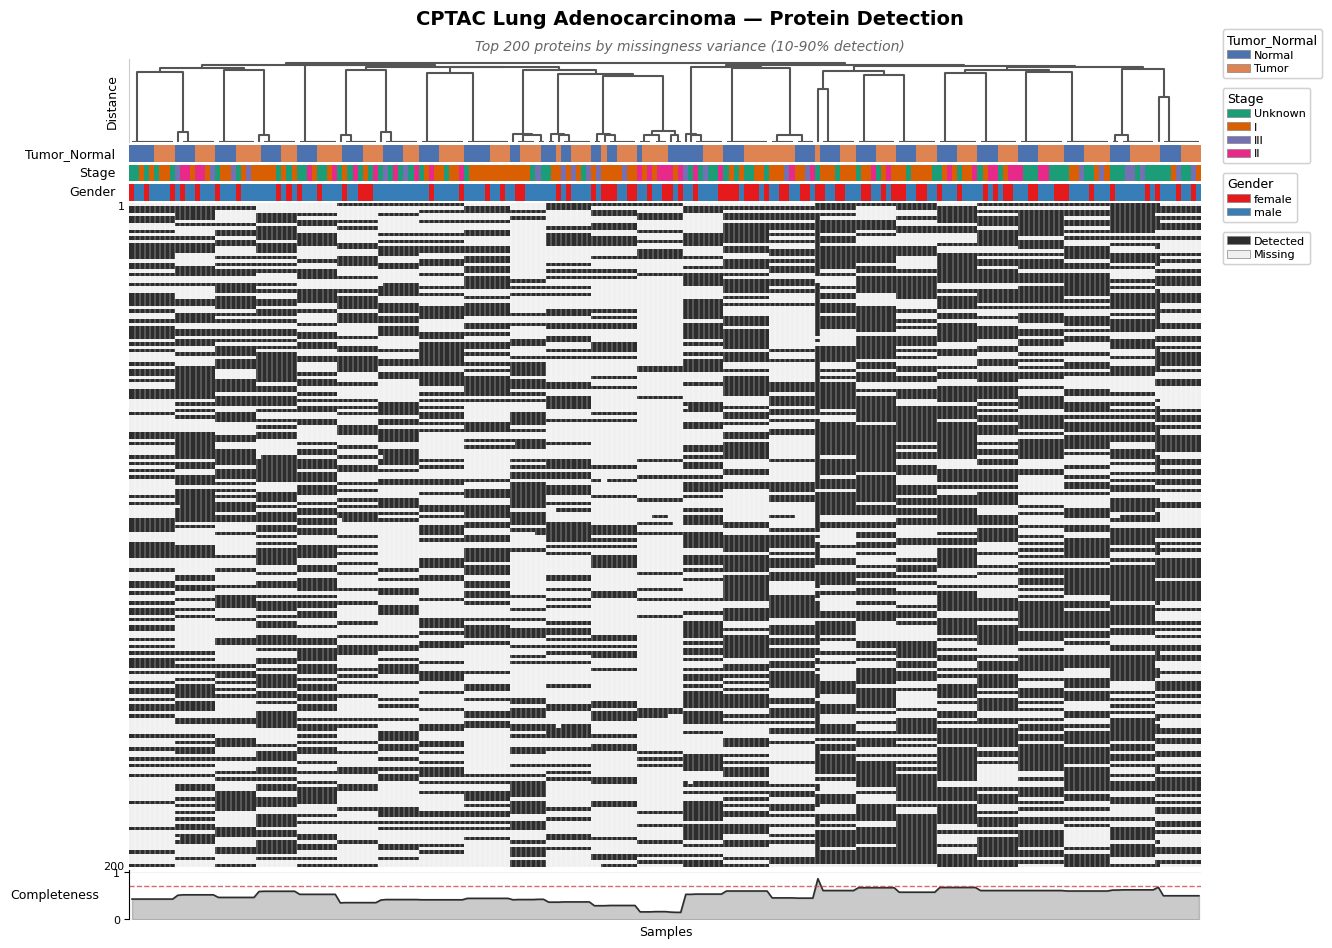

In [13]:
# MultiIndex levels: 0=Tumor_Normal, 1=Stage, 2=Gender, 3=Sample
fig = missing_matrix(
    prot_subset,
    title="CPTAC Lung Adenocarcinoma — Protein Detection",
    subtitle="Top 200 proteins by missingness variance (10-90% detection)",
    annotation_levels=[0, 1, 2],  # Tumor_Normal, Stage, Gender
    label_level=-1,  # Sample (innermost level)
    cluster_samples=True,
    show_dendrogram=True,
    completeness='below',
    completeness_threshold=0.7,
    group_summary='Tumor_Normal',
    figsize=(16, 10),
    save='output/cptac_overview.png',
    dpi=150
)
plt.show()

**Key observations:**
- Do tumor and normal samples cluster separately?
- Are there samples that cluster away from their expected group (potential QC outliers)?
- Which proteins show condition-specific missingness?

## 7. Plot 2: Split by Tumor/Normal

Side-by-side panels showing tumor and normal samples independently.
Each panel is clustered separately — this highlights proteins that are:
- **Present in Tumor, missing in Normal** → tumour-specific expression
- **Present in Normal, missing in Tumor** → potentially lost in cancer

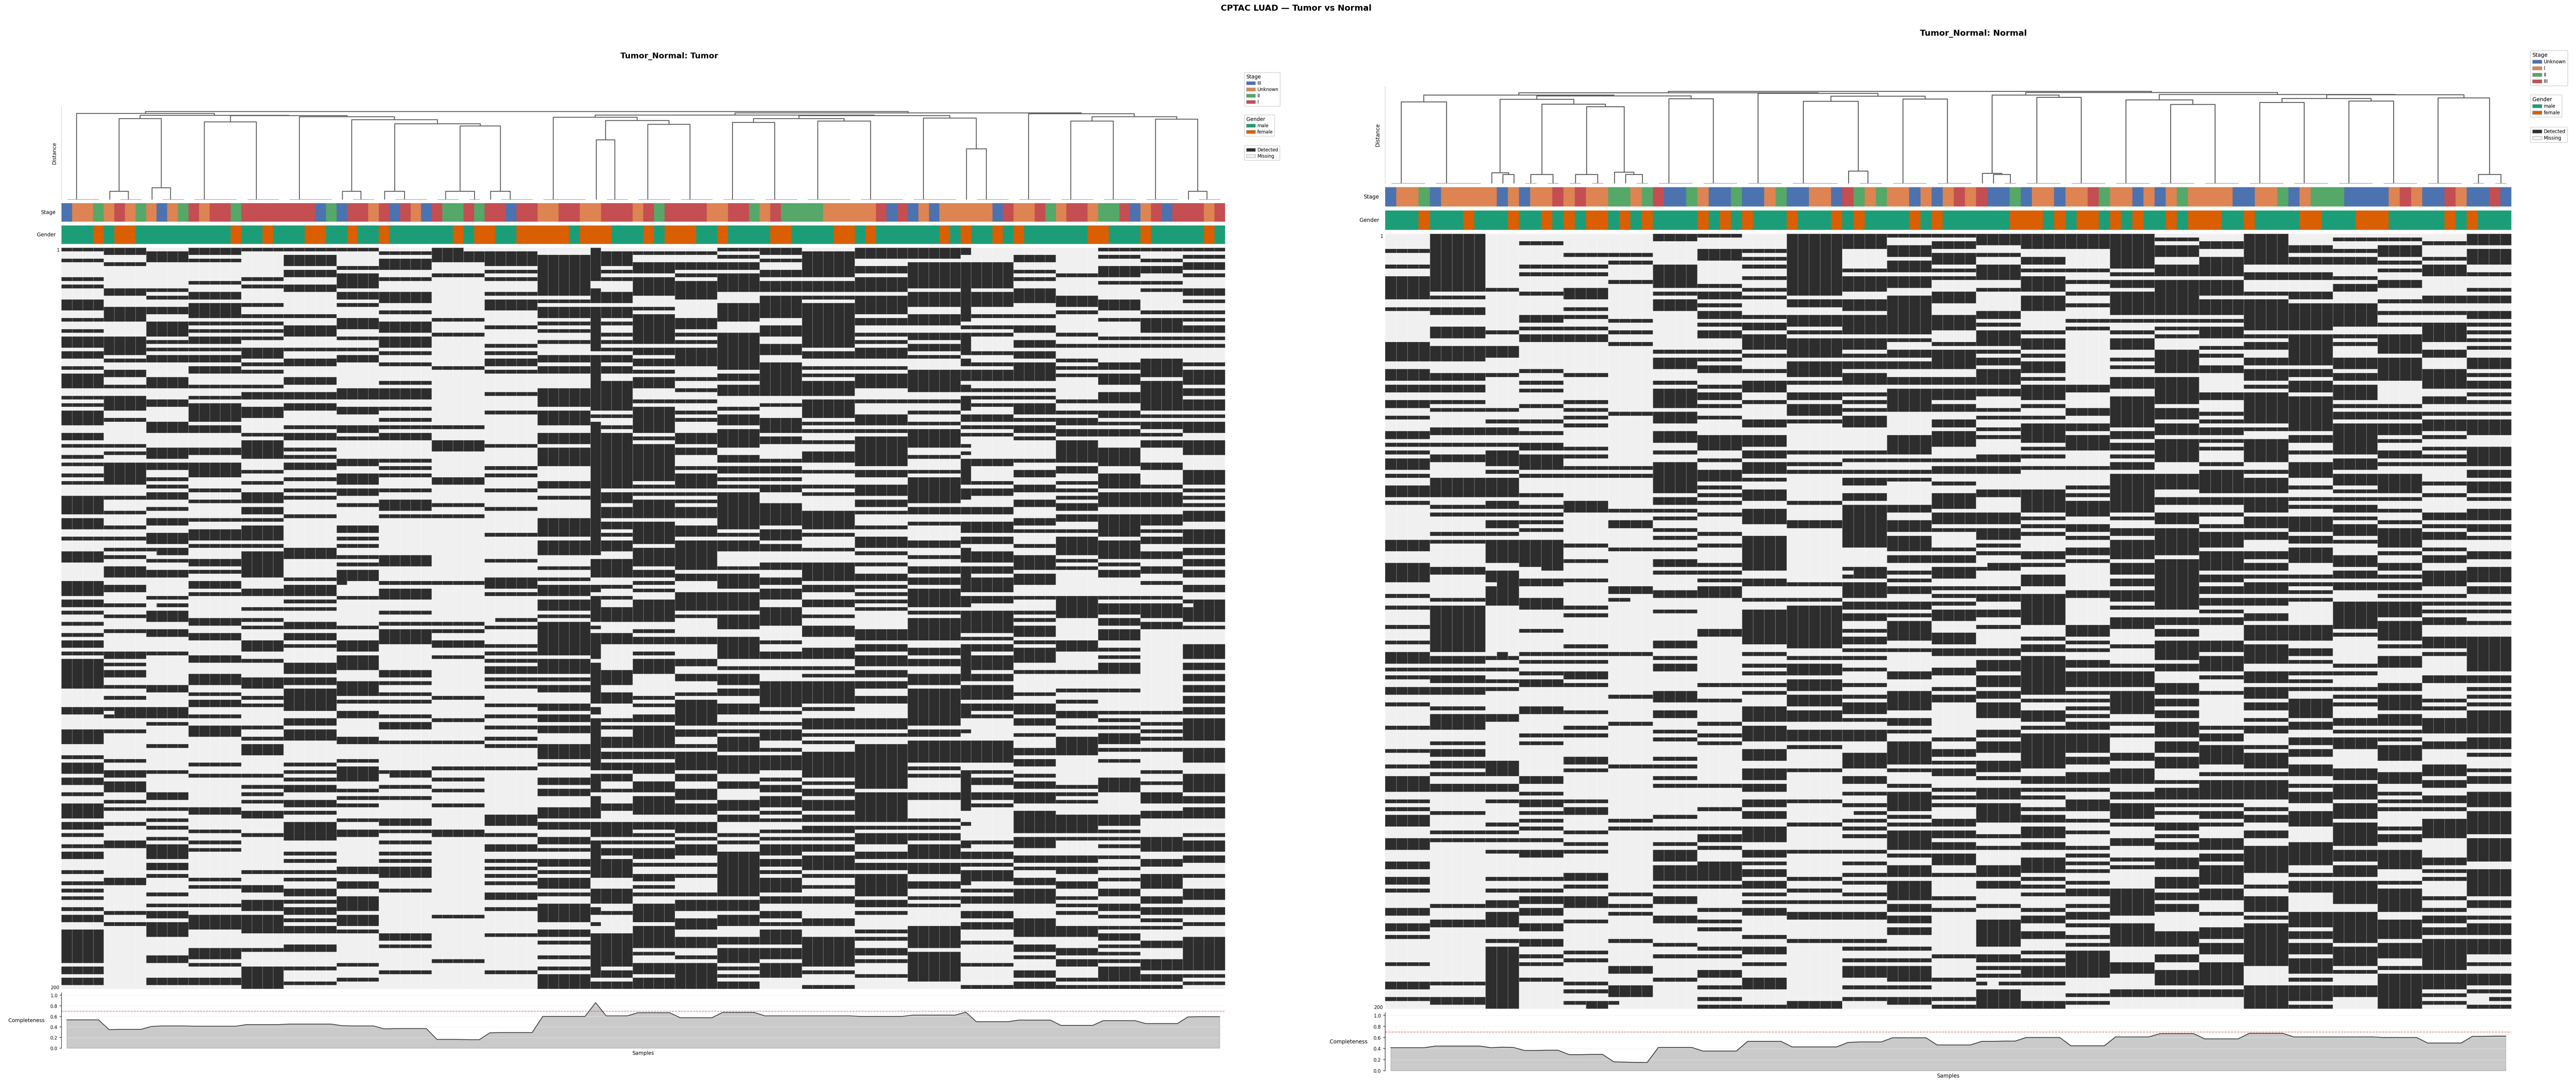

In [14]:
fig = missing_matrix(
    prot_subset,
    title="CPTAC LUAD — Tumor vs Normal",
    subtitle="Each panel independently clustered",
    split_by='Tumor_Normal',
    annotation_levels=[1, 2],  # Stage, Gender (Tumor_Normal used for split)
    label_level=-1,  # Sample
    cluster_samples=True,
    show_dendrogram=True,
    completeness='below',
    completeness_threshold=0.7,
    figsize=(18, 10),
    save='output/cptac_split.png',
    dpi=150
)
plt.show()

**Biological insight:**

Proteins that show systematic differences in detection between tumor and normal are candidates for **MNAR (missing not at random)** — they're missing because of biology, not technical noise.

This matters for downstream analysis:
- **MNAR proteins** should NOT be imputed with standard methods (KNN, median, etc.)
- They may represent true biological signal (tumor-specific expression)

## 8. Interactive Export

Generate an interactive HTML version with hover tooltips showing:
- Gene name
- Sample ID
- All annotation levels
- Detection status

In [15]:
html = missing_matrix_html(
    prot_subset,
    title="CPTAC LUAD — Interactive Missing Data Matrix",
    annotation_levels=[0, 1, 2],  # Tumor_Normal, Stage, Gender
    label_level=-1,  # Sample
    cluster_samples=True,
    completeness='below',
    completeness_threshold=0.7,
    save='output/cptac_interactive.html'
)

print("Interactive HTML saved to output/cptac_interactive.html")
print("Open in browser to explore with hover tooltips.")

Interactive HTML saved to output/cptac_interactive.html
Open in browser to explore with hover tooltips.


## 9. Abundance-by-Missingness Density Plot

This diagnostic plot reveals whether missing data follows an **MNAR** pattern — where low-abundance proteins are more likely to be missing because they fall below the detection limit of the mass spectrometer.

Each curve shows the abundance distribution of proteins with a given number of missing values:
- **Left-shifted curves** (low abundance) with high missingness = MNAR signal
- **Overlapping curves** across missingness levels = MAR (Missing At Random)

This matters for choosing an imputation strategy:
- MNAR → impute from the lower end of the distribution (e.g. Perseus-style Gaussian downshift)
- MAR → standard methods like KNN or median are appropriate

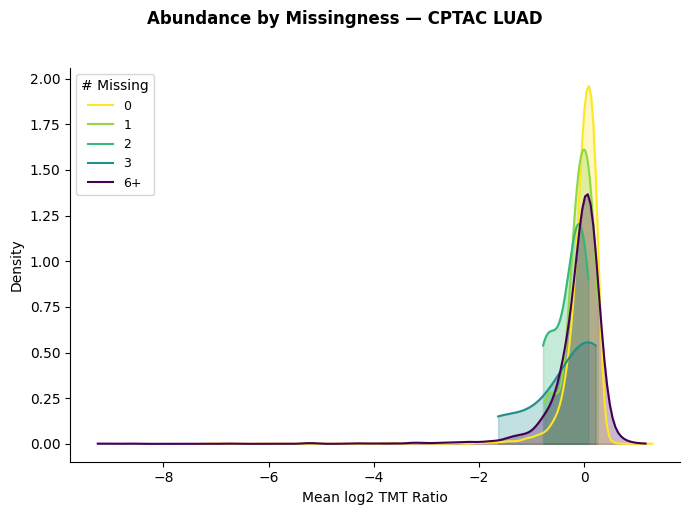

In [16]:
from mismap_qc import missing_abundance_density

# Use the full combined matrix for density plots
# so we have a full range of missingness counts across proteins
fig = missing_abundance_density(
    prot_combined,
    title="Abundance by Missingness — CPTAC LUAD",
    xlabel="Mean log2 TMT Ratio",
    save="output/cptac_density_overall.png",
)
plt.show()

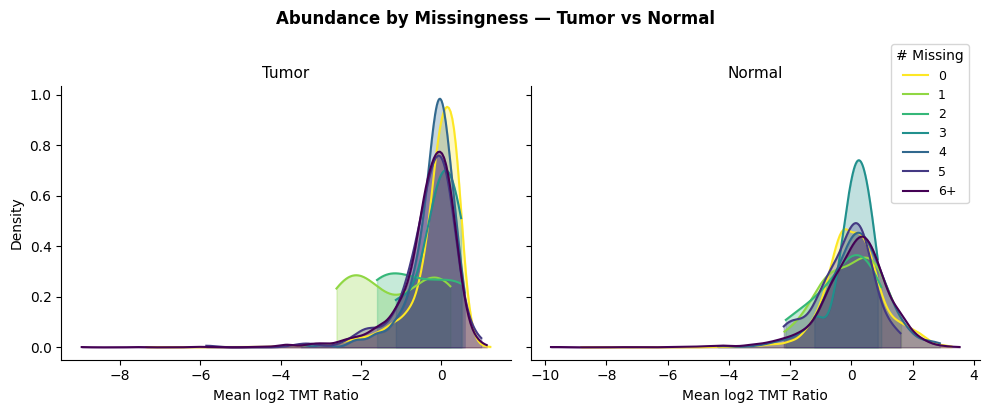

In [17]:
# Faceted by Tumor/Normal
tumor_normal_labels = ["Tumor" if c.endswith("_T") else "Normal" for c in prot_combined.columns]

fig = missing_abundance_density(
    prot_combined,
    groups=tumor_normal_labels,
    title="Abundance by Missingness — Tumor vs Normal",
    xlabel="Mean log2 TMT Ratio",
    save="output/cptac_density_split.png",
)
plt.show()

**What to look for:**
- If the curves shift left as missingness increases → strong MNAR signal, use downshift imputation
- If Tumor and Normal show different MNAR patterns → condition-specific imputation strategies may be needed
- A flat/overlapping pattern → missing data is more random, standard imputation is safer

## 10.. Comparison with Existing Tools

| Tool | Missing data viz | Clustering | Annotations | One function call |
|------|-----------------|------------|-------------|-------------------|
| **Perseus** | Binary heatmap | No | No | N/A (GUI) |
| **DEP** (R) | Binary heatmap | No | No | ~5 lines |
| **FragPipe-Analyst** | Bar charts | No | No | N/A (GUI) |
| **ComplexHeatmap** (R) | Yes | Yes | Yes | ~50 lines across 3-4 packages |
| **mismap-qc** | Yes | Yes | Yes | **1 function call** |

mismap-qc gives you publication-ready missing data visualisation with:
- Hierarchical clustering showing sample relationships
- Multi-level annotations as colour strips
- Completeness sparklines with thresholds
- Split-by-factor panels for condition comparisons
- Interactive HTML with hover tooltips

All in a single function call.

## 11.. Biological Interpretation

The missing data patterns in proteomics data tell a biological story:

1. **Proteins with high missingness in Normal but detected in Tumor**
   - Tumor-specific expression (upregulated in cancer)
   - Could be oncogenes or cancer-associated proteins

2. **Proteins with high missingness in Tumor but detected in Normal**
   - Potentially lost in cancer
   - Could be tumor suppressors or differentiation markers

3. **Samples that cluster away from their biological group**
   - Potential QC outliers (sample swap, degradation, technical issues)
   - Should be investigated before downstream analysis

4. **MNAR vs MAR distinction**
   - **MNAR**: Missing because protein is truly absent (biological)
   - **MAR**: Missing at random due to technical reasons
   - This matters for imputation method choice!

---

**This is the decision point before imputation.** Understanding whether missingness is biological (MNAR) or technical (MAR) determines which imputation method is appropriate — and whether imputation is appropriate at all.